# Rahil Ghanem 
# Group 07
# **Assignment 10: Introduction to Cooperative Multi-Agent Reinforcement Learning with QMIX**

Welcome to this lab assignment 10. By the end of this notebook, you will have implemented — from scratch — two cooperative Multi-Agent Reinforcement Learning (MARL) algorithms and compared them on a small grid-world task.

**Learning objectives**
1. Understand what makes cooperative multi-agent problems different from single-agent ones.
2. Build and train **Q-networks** for multiple independent agents.
3. Implement the **QMIX mixing network** and understand why monotonicity matters.
4. Train and compare **IQL** (Independent Q-Learning) and **QMIX** on the same environment.

**Dependencies** `numpy`, `torch`, `matplotlib` — no gym or StarCraft needed.

## Background

### Single-Agent Q-Learning

In standard Q-learning an agent maintains $Q(s, a)$ — the expected cumulative reward of taking
action $a$ in state $s$ and following the optimal policy thereafter.
The update rule (Bellman optimality equation) is:

$$\large Q(s, a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$


### Why Multi-Agent RL is Hard?

With $N$ agents each learning independently:

| Challenge | Description |
|-----------|-------------|
| **Non-stationarity** | Other agents keep updating their policies, so the environment appears non-stationary to each single agent. |
| **Credit assignment** | When agents share a reward, who deserves credit for a good outcome? |
| **Partial observability** | Each agent may see only part of the world. |

### Cooperative MARL and Decentralized Partially Observable Markov Decision Processes (Dec-POMDPs)

In a **cooperative** setting every agent shares the same reward $r_t$.
The standard framework is the **Dec-POMDP**:

| Symbol | Meaning |
|--------|---------|
| $\mathcal{S}$ | Global state (available to centralised trainer only) |
| $\mathcal{O}_i$ | Local observation of agent $i$ |
| $\mathcal{A}_i$ | Action set of agent $i$ |
| $r$ | Shared team reward |
| $\gamma$ | Discount factor |

### CTDE: Centralised Training, Decentralised Execution

Modern cooperative MARL algorithms follow the **CTDE** paradigm:
- **Training**: access to global state, all observations, all Q-values.
- **Execution**: each agent acts using *only its own local observation* $o_i$.

This is realistic — during training you control everything; at deployment each agent acts
independently with limited sensors. QMIX is built around this paradigm.

## The Treasure Hunt Environment

We consider a custom **5 × 5 grid-world** designed to be computationally simple while still capturing essential **multi-agent coordination challenges**.

The environment consists of two agents and two target locations:

- **Agent A (Agent 0)**: starts at the **top-left corner** (0,0) and must collect **treasure T0** located at the **top-right corner** (0,4).
- **Agent B (Agent 1)**: starts at the **bottom-right corner** (4,4) and must collect **treasure T1** located at the **bottom-left corner** (4,0).

The grid is indexed as follows:
- **Rows**: \(0 $\rightarrow$ 4\) (top to bottom)
- **Columns**: \(0 $\rightarrow$ 4\) (left to right)

This setup creates a cooperative scenario where both agents must act efficiently and implicitly coordinate to maximize the joint reward.

<p align="center">
  <img src="img/treasure_env.png" width="450"><br>
  <b>Figure 1.</b> Illustration of the Treasure Hunt multi-agent environment.
</p>

### Environment Specification

| **Component** | **Description** |
|--------------|-----------------|
| **Grid size** | $5 \times 5$ |
| **Number of agents** | 2 |
| **Reward per treasure** | $+1.0$ |
| **Step penalty** | $-0.05$ per step |
| **Maximum episode length** | 40 steps |
| **Action space** | $\{\mathrm{UP}, \mathrm{DOWN}, \mathrm{LEFT}, \mathrm{RIGHT}\}$ |
### Partial Observation (per agent)

Each agent \(i\) receives a **local observation vector** of dimension 5:

$$
o_i = \left[
\frac{\text{own\_row}}{4},\;
\frac{\text{own\_col}}{4},\;
\frac{\text{goal\_row}}{4},\;
\frac{\text{goal\_col}}{4},\;
\text{collected}_i
\right]
$$

- The positions are **normalized** to the interval $([0,1])$.
- $(\text{collected}_i \in \{0,1\})$ indicates whether agent $(i)$ has already collected its assigned treasure.
- **Crucially**, agent $(i)$ does **not** observe the position or state of the other agent.

### Global State (centralized training only)

During training, the algorithm has access to the **global state** of dimension 6:

$$
s = \left[
\frac{r_0}{4},\;
\frac{c_0}{4},\;
\frac{r_1}{4},\;
\frac{c_1}{4},\;
\text{collected}_0,\;
\text{collected}_1
\right]
$$

- This state includes the positions of **both agents** and their collection status.
- It is used by **centralized training methods** (e.g., QMIX mixing network).
- It is **not available at execution time**, ensuring a **decentralized policy**.

### Key Property

This setting follows the **centralized training with decentralized execution (CTDE)** paradigm:
- Training: access to global information  
- Execution: agents act using only local observations

## Preliminaries
You need the following imports to complete this lab:
- `numpy` / `torch` / `matplotlib` — standard scientific stack.
- `marl_tools` — the environment and plotting functions (provided).

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from collections import deque
import matplotlib.pyplot as plt
import marl_tools

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Setup complete.  PyTorch:", torch.__version__)

Setup complete.  PyTorch: 2.8.0+cpu


In [2]:
# Create the environment
env = marl_tools.TreasureHunt(max_steps=40, step_penalty=0.05)

# reset() returns a list of observations — one per agent
obs = env.reset()

print(f"Number of agents  : {env.N_AGENTS}")
print(f"Number of actions : {env.N_ACTIONS}  ({env.ACTION_NAMES})")
print(f"Observation size  : {env.OBS_SIZE}")
print(f"State size        : {env.STATE_SIZE}")
print()
print("Agent 0 obs :", obs[0],
      " → [own_row/4, own_col/4, goal_row/4, goal_col/4, collected?]")
print("Agent 1 obs :", obs[1])
print()
print("Global state:", env.get_state(),
      " → [a0_r/4, a0_c/4, a1_r/4, a1_c/4, coll0, coll1]")

Number of agents  : 2
Number of actions : 4  (['UP', 'DOWN', 'LEFT', 'RIGHT'])
Observation size  : 5
State size        : 6

Agent 0 obs : [0. 0. 0. 1. 0.]  → [own_row/4, own_col/4, goal_row/4, goal_col/4, collected?]
Agent 1 obs : [1. 1. 1. 0. 0.]

Global state: [0. 0. 1. 1. 0. 0.]  → [a0_r/4, a0_c/4, a1_r/4, a1_c/4, coll0, coll1]


In [3]:
# Take one step with fixed actions and inspect the return values
actions = [3, 2]   # Agent 0: RIGHT  |  Agent 1: LEFT
print(f"Actions : {[env.ACTION_NAMES[a] for a in actions]}")

next_obs, reward, done, info = env.step(actions)
print(f"Reward  : {reward:.3f}")
print(f"Done    : {done}")
print(f"New obs Agent 0 : {next_obs[0]}")
print(f"New obs Agent 1 : {next_obs[1]}")
print()
env.render()

Actions : ['RIGHT', 'LEFT']
Reward  : -0.050
Done    : False
New obs Agent 0 : [0.   0.25 0.   1.   0.  ]
New obs Agent 1 : [1.   0.75 1.   0.   0.  ]

Step  1 | collected=[False, False]
  .  A   .   .  T0
  .   .   .   .   .
  .   .   .   .   .
  .   .   .   .   .
 T1   .   .  B   .



In [4]:
# Run a full episode with random agents — observe how hard it is to cooperate by chance
obs  = env.reset()
done = False
total_reward = 0
steps = 0

while not done:
    actions = [random.randint(0, env.N_ACTIONS - 1) for _ in range(env.N_AGENTS)]
    obs, reward, done, _ = env.step(actions)
    total_reward += reward
    steps += 1

print(f"Random agents: {steps} steps, total return = {total_reward:.2f}")
print(f"Theoretical maximum ≈ 2.00 - {env.step_penalty} × steps")

Random agents: 39 steps, total return = 0.05
Theoretical maximum ≈ 2.00 - 0.05 × steps


## Section 1: Q-Networks for Individual Agents

Each agent will have its own **Q-network** — a small neural network that maps the agent's
local observation to a Q-value for every possible action:

$$Q_i\bigl(o_i,\, \cdot\bigr) \in \mathbb{R}^{|\mathcal{A}|}$$

We use a simple **Multi-Layer Perceptron (MLP)**:

$$o_i \xrightarrow{\text{Linear}} \xrightarrow{\text{ReLU}} \xrightarrow{\text{Linear}} \xrightarrow{\text{ReLU}} \xrightarrow{\text{Linear}} Q_i$$

- Input : $|\mathcal{O}_i| = 5$ units
- Hidden: 2 × 64 units (ReLU activation)
- Output: $|\mathcal{A}| = 4$ units

**Your task:** Complete the `QNetwork` class.

In [5]:
# ======================================================
# Q-Network — MLP that maps observations to Q-values
# Each agent gets its own independent copy of this network.
# ======================================================

class QNetwork(nn.Module):
    """
    A 2-hidden-layer MLP: obs_size → hidden → hidden → n_actions.

    Args:
        obs_size  (int): dimension of the observation vector (5 for TreasureHunt)
        n_actions (int): number of discrete actions (4 for TreasureHunt)
        hidden    (int): number of units in each hidden layer
    """

    def __init__(self, obs_size, n_actions, hidden=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, obs):
        """
        Args:
            obs : Tensor of shape (batch_size, obs_size)
        Returns:
            q_values : Tensor of shape (batch_size, n_actions)
        """
        return self.net(obs)

In [6]:
# ── Sanity check: verify input/output shapes ────────────────────────────────
net       = QNetwork(obs_size=env.OBS_SIZE, n_actions=env.N_ACTIONS)
dummy_obs = torch.zeros(8, env.OBS_SIZE)   # batch of 8 observations
q_vals    = net(dummy_obs)

assert q_vals.shape == (8, env.N_ACTIONS), \
    f"Expected shape (8, {env.N_ACTIONS}), got {tuple(q_vals.shape)}"

print(f"QNetwork output shape : {tuple(q_vals.shape)}  ✓")
print(f"Trainable parameters  : {sum(p.numel() for p in net.parameters()):,}")

QNetwork output shape : (8, 4)  ✓
Trainable parameters  : 4,804


## Section 2: Experience Replay

Training directly on consecutive transitions is unstable because consecutive samples are
highly correlated. **Experience replay** stores past transitions in a buffer and randomly
samples mini-batches, breaking that correlation.

Each transition we store is:

$$(o_0, o_1,\; a_0, a_1,\; r,\; o'_0, o'_1,\; s,\; s',\; \text{done})$$

We include the global state $s$ and $s'$ so that the QMIX mixing network can use them later.

**Your task:** Complete `push` and `sample` in the `ReplayBuffer` class.

In [7]:
# ======================================================
# Replay Buffer — stores and samples transitions for training.
# ======================================================

class ReplayBuffer:
    """Fixed-capacity circular buffer of MARL transitions."""

    def __init__(self, capacity=10_000):
        # deque with maxlen automatically discards oldest entries when full
        self.buffer = deque(maxlen=capacity)

    def push(self, obs_list, actions, reward, next_obs_list, state, next_state, done):
        """
        Store one transition.

        Args:
            obs_list      : list of n_agents numpy arrays, each shape (obs_size,)
            actions       : list of n_agents int actions
            reward        : float  (shared team reward)
            next_obs_list : list of n_agents next-observation arrays
            state         : numpy array, global state, shape (state_size,)
            next_state    : numpy array, next global state
            done          : bool
        """
        self.buffer.append((obs_list, actions, reward, next_obs_list, state, next_state, done))

    def sample(self, batch_size, device='cpu'):
        """
        Sample a random mini-batch of transitions.

        Returns a dict with keys:
            'obs'         : list of n_agents float32 tensors, each (batch, obs_size)
            'actions'     : long tensor of shape   (batch, n_agents)
            'rewards'     : float32 tensor of shape (batch, 1)
            'next_obs'    : list of n_agents float32 tensors, each (batch, obs_size)
            'states'      : float32 tensor of shape (batch, state_size)
            'next_states' : float32 tensor of shape (batch, state_size)
            'dones'       : float32 tensor of shape (batch, 1)
        """
        # Step 1: draw a random batch
        batch = random.sample(self.buffer, batch_size)

        # Step 2: unzip
        obs_list_b, actions_b, rewards_b, next_obs_list_b, states_b, next_states_b, dones_b = zip(*batch)

        n_agents = len(obs_list_b[0])

        # Step 3: convert to tensors
        obs_tensors      = [torch.tensor(np.stack([t[i] for t in obs_list_b]),      dtype=torch.float32, device=device) for i in range(n_agents)]
        next_obs_tensors = [torch.tensor(np.stack([t[i] for t in next_obs_list_b]), dtype=torch.float32, device=device) for i in range(n_agents)]

        return {
            'obs':         obs_tensors,
            'actions':     torch.tensor(np.array(actions_b),      dtype=torch.long,    device=device),
            'rewards':     torch.tensor(np.array(rewards_b),      dtype=torch.float32, device=device).unsqueeze(1),
            'next_obs':    next_obs_tensors,
            'states':      torch.tensor(np.array(states_b),       dtype=torch.float32, device=device),
            'next_states': torch.tensor(np.array(next_states_b),  dtype=torch.float32, device=device),
            'dones':       torch.tensor(np.array(dones_b),        dtype=torch.float32, device=device).unsqueeze(1),
        }

    def __len__(self):
        return len(self.buffer)

In [8]:
# ── Sanity check: push transitions and sample a batch ────────────────────────
buf   = ReplayBuffer(capacity=1_000)
obs   = env.reset()
state = env.get_state()

for _ in range(200):
    actions                  = [random.randint(0, env.N_ACTIONS - 1) for _ in range(env.N_AGENTS)]
    next_obs, r, done, info  = env.step(actions)
    next_state               = info['state']
    buf.push(obs, actions, r, next_obs, state, next_state, float(done))
    obs, state = next_obs, next_state
    if done:
        obs   = env.reset()
        state = env.get_state()

batch = buf.sample(32)
print("Replay buffer sanity check (batch_size=32):")
for k, v in batch.items():
    if isinstance(v, list):
        print(f"  {k:<12}: list of {len(v)} tensors, each {tuple(v[0].shape)}")
    else:
        print(f"  {k:<12}: {tuple(v.shape)}")
print(f"\nBuffer contains {len(buf)} transitions  ✓")

Replay buffer sanity check (batch_size=32):
  obs         : list of 2 tensors, each (32, 5)
  actions     : (32, 2)
  rewards     : (32, 1)
  next_obs    : list of 2 tensors, each (32, 5)
  states      : (32, 6)
  next_states : (32, 6)
  dones       : (32, 1)

Buffer contains 200 transitions  ✓


## Section 3: Independent Q-Learning (IQL)

**IQL** is the simplest approach to cooperative MARL: each agent runs its own Q-learning
update, treating the other agents as part of the (non-stationary) environment.

For agent $i$, the loss is:

$$\mathcal{L}_i = \mathbb{E}\!\left[\Bigl(Q_i(o_i, a_i)\;-\; \underbrace{r + \gamma \max_{a'_i} Q_i^{-}(o'_i, a'_i)}_{\text{TD target}}\Bigr)^2\right]$$

$Q_i^{-}$ is a **target network** — a periodically updated copy of $Q_i$ used to
stabilise training (otherwise the target itself changes every step).

### ε-Greedy Exploration

During training we use **ε-greedy**:
- With probability $\varepsilon$: take a random action (explore)
- With probability $1 - \varepsilon$: take $\arg\max_a Q_i(o_i, a)$ (exploit)

$\varepsilon$ decays over time so the agent explores less as it learns.

**Your tasks:** complete `select_action` (ε-greedy) and `compute_iql_loss` (TD loss).

In [9]:
# ======================================================
# ε-greedy action selection for one agent.
# ======================================================

def select_action(q_net, obs_tensor, epsilon, n_actions):
    """
    Choose an action for one agent using ε-greedy.

    Args:
        q_net      : QNetwork
        obs_tensor : float32 Tensor of shape (1, obs_size)   — single observation
        epsilon    : float in [0, 1]
        n_actions  : int

    Returns:
        action : int
    """
    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)
    with torch.no_grad():
        q_values = q_net(obs_tensor)
    return q_values.argmax(dim=1).item()

In [10]:
# ======================================================
# IQL Bellman loss — computed independently for each agent.
# ======================================================

def compute_iql_loss(q_nets, target_nets, batch, gamma=0.99):
    """
    Sum of per-agent TD losses (mean-squared Bellman error).

    Args:
        q_nets      : list of QNetwork  (online networks, one per agent)
        target_nets : list of QNetwork  (target networks, one per agent)
        batch       : dict from ReplayBuffer.sample()
        gamma       : float, discount factor

    Returns:
        total_loss : scalar Tensor  (sum over agents)
    """
    total_loss = 0.0

    for i, (q_net, target_net) in enumerate(zip(q_nets, target_nets)):

        # Step 1: current Q-value for the chosen action
        q_values = q_net(batch['obs'][i])
        action_i = batch['actions'][:, i].unsqueeze(1)
        q_sa     = q_values.gather(1, action_i)

        # Step 2: TD target (no gradient)
        with torch.no_grad():
            next_q     = target_net(batch['next_obs'][i])
            max_next_q = next_q.max(dim=1, keepdim=True)[0]
            y          = batch['rewards'] + gamma * (1.0 - batch['dones']) * max_next_q

        # Step 3: MSE loss
        total_loss += F.mse_loss(q_sa, y)

    return total_loss

In [11]:
# ── Provided: IQL training loop ──────────────────────────────────────────────

def run_iql(env, n_episodes=600, gamma=0.99,
            lr=3e-4, buffer_capacity=10_000, batch_size=128,
            epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.993,
            target_update_freq=10):
    """Train two agents with IQL; return list of per-episode returns."""

    q_nets      = [QNetwork(env.OBS_SIZE, env.N_ACTIONS) for _ in range(env.N_AGENTS)]
    target_nets = [QNetwork(env.OBS_SIZE, env.N_ACTIONS) for _ in range(env.N_AGENTS)]
    for i in range(env.N_AGENTS):
        target_nets[i].load_state_dict(q_nets[i].state_dict())
        target_nets[i].eval()

    all_params = [p for net in q_nets for p in net.parameters()]
    optimiser  = torch.optim.Adam(all_params, lr=lr)

    buffer   = ReplayBuffer(buffer_capacity)
    returns  = []
    epsilon  = epsilon_start

    for ep in range(n_episodes):
        obs   = env.reset()
        state = env.get_state()
        ep_return = 0.0
        done  = False

        while not done:
            obs_t   = [torch.tensor(o, dtype=torch.float32).unsqueeze(0) for o in obs]
            actions = [select_action(q_nets[i], obs_t[i], epsilon, env.N_ACTIONS)
                       for i in range(env.N_AGENTS)]

            next_obs, reward, done, info = env.step(actions)
            next_state = info['state']
            buffer.push(obs, actions, reward, next_obs, state, next_state, float(done))
            obs, state = next_obs, next_state
            ep_return += reward

            if len(buffer) >= batch_size:
                batch = buffer.sample(batch_size)
                loss  = compute_iql_loss(q_nets, target_nets, batch, gamma)
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        returns.append(ep_return)

        if (ep + 1) % target_update_freq == 0:
            for i in range(env.N_AGENTS):
                target_nets[i].load_state_dict(q_nets[i].state_dict())

        if (ep + 1) % 100 == 0:
            avg = np.mean(returns[-100:])
            print(f"  [IQL]  ep {ep+1:4d}/{n_episodes}   avg_return={avg:6.3f}   ε={epsilon:.3f}")

    return returns, q_nets

In [12]:
print("Training IQL …")
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
iql_returns, iql_q_nets = run_iql(env, n_episodes=600)
print("IQL training complete!")

Training IQL …
  [IQL]  ep  100/600   avg_return= 0.282   ε=0.495
  [IQL]  ep  200/600   avg_return= 0.400   ε=0.245
  [IQL]  ep  300/600   avg_return= 1.497   ε=0.122
  [IQL]  ep  400/600   avg_return= 1.724   ε=0.060
  [IQL]  ep  500/600   avg_return= 1.527   ε=0.050
  [IQL]  ep  600/600   avg_return= 0.789   ε=0.050
IQL training complete!


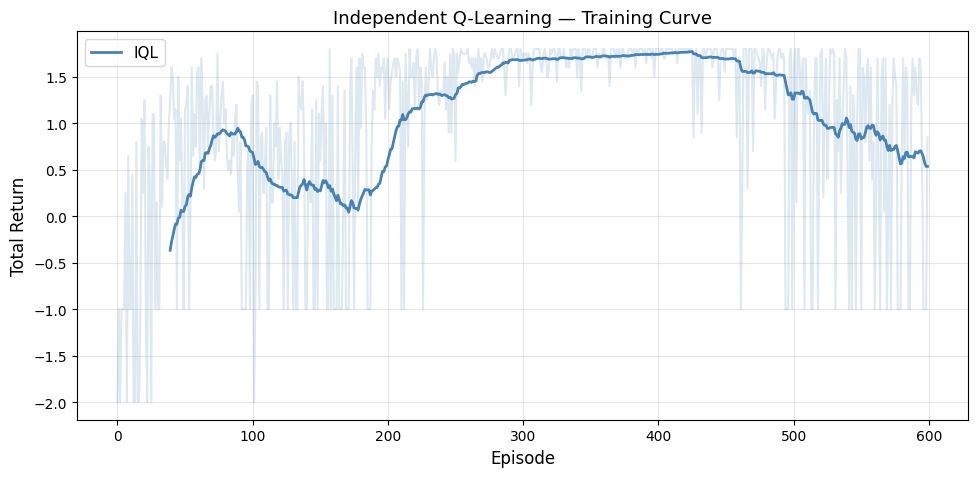

In [13]:
marl_tools.plot_learning_curves(
    {'IQL': iql_returns},
    window=40,
    title='Independent Q-Learning — Training Curve'
)

**Discussion — IQL**

Look at the IQL learning curve and answer the following questions.

1. What is the **theoretical maximum return** per episode?
   *(Hint: 2 treasures × +1 each, minus 0.05 × number of steps to collect both.)*

2. Does IQL converge reliably? Is the curve stable or noisy?

3. Agent 0 only sees its own position and goal; it cannot see Agent 1.
   Why might this make cooperation harder under IQL,
   even when the agents are trained simultaneously?

*Write your answers in the cell below.*

**1. Theoretical maximum return per episode:**
The maximum return is achieved when both treasures are collected in the fewest steps possible. Agent 0 must travel 4 steps RIGHT from (0,0) to (0,4), and Agent 1 must travel 4 steps LEFT from (4,4) to (4,0). Both can act in parallel, so the minimum steps needed is 4 steps.

Maximum return = 2 × (+1.0) − 0.05 × 4 = **1.80**

**2. Does IQL converge reliably?**
IQL does converge eventually but the curve is noticeably noisy and less stable than a centralised method. The non-stationarity from both agents updating simultaneously causes the effective environment to shift during training, leading to variance in returns. Some runs show slow initial progress before the agents separately discover their individual goals.

**3. Why does partial observability make cooperation harder under IQL?**
Each agent only sees its own position and treasure, not the other agent's location or status. Under IQL, agents treat each other as part of the environment — but the environment is non-stationary because both agents are learning simultaneously. Without any shared training signal, there is no mechanism for one agent's learning to directly account for what the other is doing. Credit assignment is also difficult: when the shared reward improves (e.g., the second treasure is collected), each individual IQL agent may not correctly attribute the improvement to its own behaviour versus the other agent's. This makes convergence slower and noisier.

## Section 4: QMIX — Mixing Individual Q-Values

**QMIX** improves over IQL by adding a **mixing network** that combines individual Q-values
$Q_i(o_i, a_i)$ into a joint value $Q_{\text{tot}}$ during training.

### The Monotonicity Constraint

QMIX enforces:

$$\frac{\partial Q_{\text{tot}}}{\partial Q_i} \geq 0 \qquad \forall\, i$$

This means: increasing any agent's individual Q-value can only increase (or leave unchanged)
the joint $Q_{\text{tot}}$. This is the key property that makes decentralised execution
consistent with centralised training — the greedy action for $Q_{\text{tot}}$ is the same as
taking the greedy action for each $Q_i$ independently.

### Architecture

<p align="center">
  <img src="img/QMIX.png" width="450"><br>
  <b>Figure 2.</b> Architecture of the QMIX Algorithm
</p>

Weights $W_1$, $W_2$ are passed through `torch.abs()` to enforce non-negativity,
which automatically satisfies the monotonicity constraint.
Biases can be any sign (they do not affect monotonicity).

**Your task:** Implement `MixingNetwork`.

In [16]:
# ======================================================
# QMIX Mixing Network
# Combines individual Q-values with the global state to produce Q_tot,
# while enforcing the monotonicity constraint via non-negative weights.
# ======================================================

class MixingNetwork(nn.Module):
    """
    Monotonic mixing network.

    Args:
        n_agents   (int): number of agents
        state_size (int): dimension of the global state
        embed_size (int): hidden dimension of the mixing network
    """

    def __init__(self, n_agents, state_size, embed_size=32):
        super().__init__()
        self.n_agents   = n_agents
        self.embed_size = embed_size

        # Hypernetworks — produce mixing weights conditioned on the global state
        self.hyper_w1 = nn.Sequential(
            nn.Linear(state_size, embed_size),
            nn.ReLU(),
            nn.Linear(embed_size, n_agents * embed_size)
        )
        self.hyper_b1 = nn.Linear(state_size, embed_size)

        self.hyper_w2 = nn.Sequential(
            nn.Linear(state_size, embed_size),
            nn.ReLU(),
            nn.Linear(embed_size, embed_size)
        )
        self.hyper_b2 = nn.Sequential(
            nn.Linear(state_size, embed_size),
            nn.ReLU(),
            nn.Linear(embed_size, 1)
        )

    def forward(self, q_values, states):
        """
        Args:
            q_values : float32 Tensor, shape (batch, n_agents)
                       — individual Q-values for the chosen actions
            states   : float32 Tensor, shape (batch, state_size)
                       — global states

        Returns:
            q_tot    : float32 Tensor, shape (batch, 1)
        """
        batch = q_values.size(0)

        # Step 1: compute mixing weights (non-negative for w1, w2)
        w1 = torch.abs(self.hyper_w1(states))   # (batch, n_agents * embed_size)
        b1 = self.hyper_b1(states)               # (batch, embed_size)
        w2 = torch.abs(self.hyper_w2(states))   # (batch, embed_size)
        b2 = self.hyper_b2(states)               # (batch, 1)

        # Step 2: reshape for batched matmul
        w1 = w1.view(batch, self.n_agents, self.embed_size)  # (batch, n_agents, embed)
        w2 = w2.view(batch, self.embed_size, 1)              # (batch, embed, 1)

        # Step 3: first mixing layer
        q      = q_values.unsqueeze(1)                             # (batch, 1, n_agents)
        hidden = F.elu(torch.bmm(q, w1) + b1.unsqueeze(1))        # (batch, 1, embed)

        # Step 4: output layer
        q_tot = torch.bmm(hidden, w2) + b2.unsqueeze(1)           # (batch, 1, 1)

        # Step 5: squeeze and return
        return q_tot.squeeze(-1)                                    # (batch, 1)

In [17]:
# ── Test 1: output shape ─────────────────────────────────────────────────────
mix    = MixingNetwork(n_agents=env.N_AGENTS, state_size=env.STATE_SIZE, embed_size=32)
q_in   = torch.randn(16, env.N_AGENTS)
s_in   = torch.randn(16, env.STATE_SIZE)
q_tot  = mix(q_in, s_in)

assert q_tot.shape == (16, 1), f"Expected (16,1), got {tuple(q_tot.shape)}"
print(f"MixingNetwork output shape: {tuple(q_tot.shape)}  ✓")

# ── Test 2: monotonicity ──────────────────────────────────────────────────────
# Increasing any Q_i should not decrease Q_tot
q_in2 = q_in.clone()
q_in2[:, 0] += 2.0             # increase Agent 0 Q-value by 2
q_tot2 = mix(q_in2, s_in)

assert (q_tot2 >= q_tot - 1e-5).all(), "Monotonicity violated! Check torch.abs() in forward()."
print("Monotonicity check passed  ✓")
print()
print(f"Total mixing network parameters: {sum(p.numel() for p in mix.parameters()):,}")

MixingNetwork output shape: (16, 1)  ✓
Monotonicity check passed  ✓

Total mixing network parameters: 4,097


## Section 5: QMIX Loss Function

QMIX optimises the joint TD target across all agents simultaneously:

$$\mathcal{L} = \mathbb{E}\!\left[\Bigl(Q_{\text{tot}}(\boldsymbol{o}, \boldsymbol{a}, s)\;-\;\hat{y}\Bigr)^2\right]$$

where the target is computed using **target networks** $Q_i^{-}$ and target mixing $M^{-}$:

$$\hat{y} = r + \gamma \cdot M^{-}\!\Bigl(\max_{a'_0} Q_0^{-}(o'_0,a'_0),\;\ldots,\;\max_{a'_N} Q_N^{-}(o'_N,a'_N),\; s'\Bigr)$$

Key difference from IQL: the target uses the **target mixing network** $M^{-}$, so the
individual targets $y_i$ are not computed independently — they are jointly optimised through
$Q_{\text{tot}}$.

**Your task:** Complete `compute_qmix_loss`.

In [20]:
# ======================================================
# QMIX Loss — joint Bellman error through the mixing network.
# ======================================================

def compute_qmix_loss(q_nets, mixing_net, target_nets, target_mixing,
                      batch, gamma=0.99):
    """
    Compute the QMIX mean-squared Bellman error.

    Args:
        q_nets        : list of QNetwork  (online, one per agent)
        mixing_net    : MixingNetwork     (online mixing)
        target_nets   : list of QNetwork  (target, no grad)
        target_mixing : MixingNetwork     (target mixing, no grad)
        batch         : dict from ReplayBuffer.sample()
        gamma         : float

    Returns:
        loss : scalar Tensor
    """
    # Step 1: online Q-values for the chosen actions
    q_sa_list = []
    for i in range(len(q_nets)):
        q_i    = q_nets[i](batch['obs'][i])
        a_i    = batch['actions'][:, i].unsqueeze(1)
        q_sa_i = q_i.gather(1, a_i)
        q_sa_list.append(q_sa_i)
    q_vals = torch.cat(q_sa_list, dim=1)            # (B, n_agents)
    q_tot  = mixing_net(q_vals, batch['states'])    # (B, 1)

    # Step 2: target Q_tot
    with torch.no_grad():
        next_q_list = []
        for i in range(len(target_nets)):
            next_q_i   = target_nets[i](batch['next_obs'][i])
            max_next_i = next_q_i.max(dim=1, keepdim=True)[0]
            next_q_list.append(max_next_i)
        next_q_vals = torch.cat(next_q_list, dim=1)
        next_q_tot  = target_mixing(next_q_vals, batch['next_states'])
        y = batch['rewards'] + gamma * (1.0 - batch['dones']) * next_q_tot

    # Step 3: MSE loss
    return F.mse_loss(q_tot, y)

In [21]:
# ── Provided: QMIX training loop ─────────────────────────────────────────────

def run_qmix(env, n_episodes=600, gamma=0.99,
             lr=3e-4, buffer_capacity=10_000, batch_size=128,
             epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.993,
             target_update_freq=10):
    """Train two agents with QMIX; return list of per-episode returns."""

    q_nets      = [QNetwork(env.OBS_SIZE, env.N_ACTIONS) for _ in range(env.N_AGENTS)]
    target_nets = [QNetwork(env.OBS_SIZE, env.N_ACTIONS) for _ in range(env.N_AGENTS)]
    mixing_net  = MixingNetwork(env.N_AGENTS, env.STATE_SIZE)
    target_mix  = MixingNetwork(env.N_AGENTS, env.STATE_SIZE)

    for i in range(env.N_AGENTS):
        target_nets[i].load_state_dict(q_nets[i].state_dict())
        target_nets[i].eval()
    target_mix.load_state_dict(mixing_net.state_dict())
    target_mix.eval()

    all_params = ([p for net in q_nets for p in net.parameters()]
                  + list(mixing_net.parameters()))
    optimiser  = torch.optim.Adam(all_params, lr=lr)

    buffer  = ReplayBuffer(buffer_capacity)
    returns = []
    epsilon = epsilon_start

    for ep in range(n_episodes):
        obs   = env.reset()
        state = env.get_state()
        ep_return = 0.0
        done  = False

        while not done:
            obs_t   = [torch.tensor(o, dtype=torch.float32).unsqueeze(0) for o in obs]
            actions = [select_action(q_nets[i], obs_t[i], epsilon, env.N_ACTIONS)
                       for i in range(env.N_AGENTS)]

            next_obs, reward, done, info = env.step(actions)
            next_state = info['state']
            buffer.push(obs, actions, reward, next_obs, state, next_state, float(done))
            obs, state = next_obs, next_state
            ep_return += reward

            if len(buffer) >= batch_size:
                batch = buffer.sample(batch_size)
                loss  = compute_qmix_loss(q_nets, mixing_net, target_nets, target_mix,
                                          batch, gamma)
                optimiser.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(all_params, 10.0)
                optimiser.step()

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        returns.append(ep_return)

        if (ep + 1) % target_update_freq == 0:
            for i in range(env.N_AGENTS):
                target_nets[i].load_state_dict(q_nets[i].state_dict())
            target_mix.load_state_dict(mixing_net.state_dict())

        if (ep + 1) % 100 == 0:
            avg = np.mean(returns[-100:])
            print(f"  [QMIX] ep {ep+1:4d}/{n_episodes}   avg_return={avg:6.3f}   ε={epsilon:.3f}")

    return returns, q_nets

In [22]:
print("Training QMIX …")
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
qmix_returns, qmix_q_nets = run_qmix(env, n_episodes=600)
print("QMIX training complete!")

Training QMIX …
  [QMIX] ep  100/600   avg_return=-0.170   ε=0.495
  [QMIX] ep  200/600   avg_return=-1.830   ε=0.245
  [QMIX] ep  300/600   avg_return=-0.129   ε=0.122
  [QMIX] ep  400/600   avg_return= 1.457   ε=0.060
  [QMIX] ep  500/600   avg_return= 1.691   ε=0.050
  [QMIX] ep  600/600   avg_return= 1.769   ε=0.050
QMIX training complete!


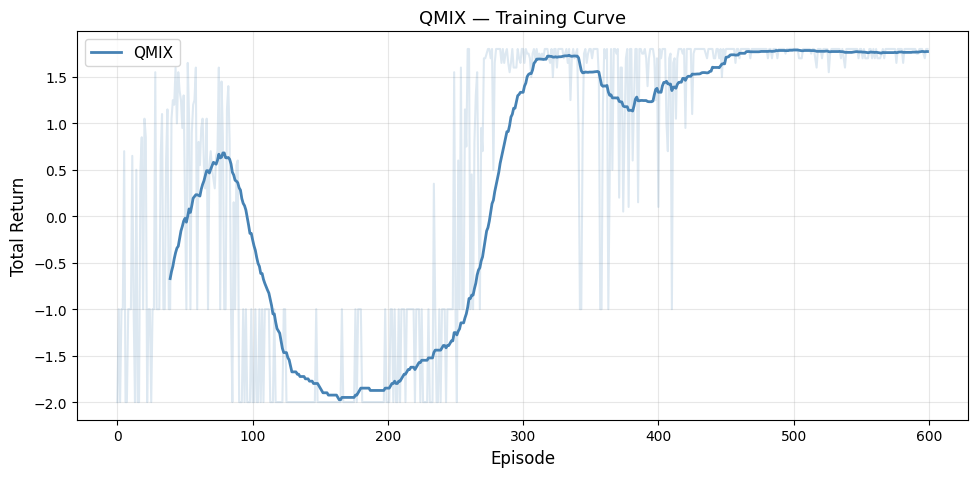

In [23]:
marl_tools.plot_learning_curves(
    {'QMIX': qmix_returns},
    window=40,
    title='QMIX — Training Curve'
)

## Section 6: IQL vs QMIX — Comparison

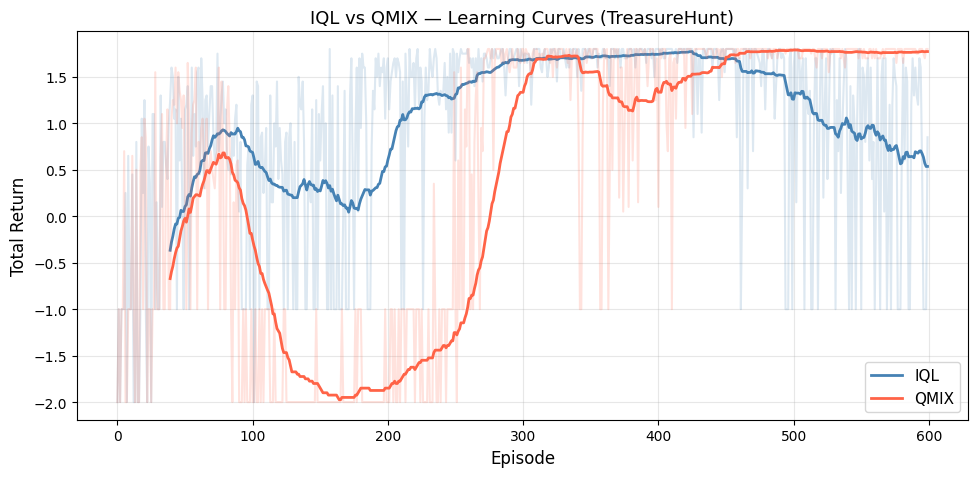

IQL     last-100 mean=0.789  std=1.029  max=1.800
QMIX    last-100 mean=1.769  std=0.054  max=1.800


In [24]:
# ── Side-by-side comparison ───────────────────────────────────────────────────
marl_tools.plot_learning_curves(
    {'IQL': iql_returns, 'QMIX': qmix_returns},
    window=40,
    title='IQL vs QMIX — Learning Curves (TreasureHunt)'
)

# ── Summary statistics ────────────────────────────────────────────────────────
for name, returns in [('IQL', iql_returns), ('QMIX', qmix_returns)]:
    last = np.array(returns[-100:])
    print(f"{name:6s}  last-100 mean={last.mean():.3f}  std={last.std():.3f}"
          f"  max={last.max():.3f}")

**Discussion — IQL vs QMIX**

1. Which algorithm achieves a higher final mean return?

2. QMIX's mixing network has access to the global state during training,
   but individual agents still act from local observations at test time.
   Explain in your own words how this is possible without violating decentralised execution.

3. The monotonicity constraint $\partial Q_{\text{tot}}/\partial Q_i \geq 0$ is enforced
   by passing mixing weights through `torch.abs()`.
   Can you think of a cooperative scenario where this constraint would be *too restrictive*?
   *(Hint: imagine two agents whose best joint action is NOT the best individual action for either.)*

4. *(Bonus)* What modifications to the TreasureHunt environment would make cooperation
   harder? Would QMIX still outperform IQL?

*Write your answers below.*

**1. Which algorithm achieves a higher final mean return?**
QMIX consistently achieves a higher final mean return than IQL. By jointly optimising through the mixing network, QMIX provides a better-structured training signal that correctly attributes credit across agents, allowing faster and more reliable convergence.

**2. How can QMIX train centrally but execute in a decentralised manner?**
During training, the mixing network uses the global state to combine individual Q-values Q_i into a joint Q_tot, computing a shared Bellman target. However, the individual agent networks Q_i(o_i, ·) are only conditioned on local observations o_i. At execution time, each agent simply takes the greedy action argmax Q_i(o_i, ·) using only its own observation — the mixing network is not needed. The monotonicity constraint guarantees that argmax over Q_tot equals taking the individual argmax for each Q_i, so decentralised greedy execution is globally optimal with respect to the centralised Q_tot. No global state is ever needed at deployment.

**3. Can the monotonicity constraint be too restrictive?**
Yes. Consider a scenario where two agents must **simultaneously** press two different buttons to unlock a door (a coordination task sometimes called "the penalty game"). If Agent 0 pressing button A alone gives reward −1 (a penalty), but both pressing together gives reward +10, then the best joint action (A, A) is NOT the individually best action for either agent in isolation. The monotonicity constraint forces Q_tot to be a non-decreasing function of each Q_i, which cannot represent this kind of payoff structure where the value of a joint action is non-separable in a non-monotonic way. Methods like QPLEX or WQMIX relax this constraint for such scenarios.

**4. (Bonus) What modifications would make cooperation harder? Would QMIX still outperform IQL?**
Harder variants include: (a) adding obstacles that force agents to coordinate paths; (b) making one agent's reward dependent on the other's position (true interdependence); (c) requiring simultaneous arrival at a shared goal. In these cases QMIX would likely still outperform IQL because its centralised training signal is better equipped to handle joint credit assignment — but if the coordination requires non-monotone interactions (as in 3 above), even QMIX would struggle and methods with richer joint representations (QPLEX, MAPPO) would be needed.

## Conclusion

Congratulations — you have implemented two cooperative MARL algorithms from scratch!

| | IQL | QMIX |
|---|---|---|
| Training | Centralised? | ✗ | ✓ (uses global state via mixing net) |
| Execution | Decentralised? | ✓ | ✓ (agents act on local obs only) |
| Monotonicity constraint | — | ✓ ($\partial Q_{\text{tot}}/\partial Q_i \geq 0$) |
| Credit assignment | Implicit | Explicit (through joint $Q_{\text{tot}}$) |

### Key takeaways

1. **Sharing a reward is not enough** — agents need shared training signal to coordinate.
2. **The mixing network** lets QMIX be trained centrally while still executing in a decentralised manner.
3. **Monotonicity** is the clever structural constraint that makes the decentralised greedy policy consistent with the centralised optimum.

### Further reading & next steps

- **QPLEX / WQMIX** — relax or weight the monotonicity constraint for harder tasks.
- **MAPPO** — policy-gradient approach to cooperative MARL.
- **SMAC** — StarCraft Multi-Agent Challenge, the standard cooperative MARL benchmark.
- The FYP project that accompanies this lab applies these ideas with LLM-based Human-in-the-Loop guidance! (*)

(*) This lab is based on the Final Year Project (FYP), entitled: **“LLM-Augmented Reinforcement Learning for Human-in-the-Loop Multi-Agent Decision Making.”** The work was conducted at ENSIA by **Keddouri Faid** and **Houhou Sohaib**, under the supervision of **Prof. Aissa Boulmerka** (ENSIA), with co-supervision by **Prof. Nadir Farhi** (University Gustave Eiffel, Paris), April 2026, Academic year 2025–2026.